<a href="https://colab.research.google.com/github/Sriharan-Thirumurthi/MST-Project/blob/main/ML_based_asset_choosing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

# Download TSLA stock data for 1 year
tsla_data = yf.download('TSLA', period='1y', auto_adjust=True)

# Download USD/INR exchange rate data for 1 year
usd_inr_data = yf.download('INR=X', period='1y', auto_adjust=True)

tsla_data.head()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2024-03-15,163.570007,165.179993,160.759995,163.160004,96971900
2024-03-18,173.800003,174.720001,165.899994,170.020004,108214400
2024-03-19,171.320007,172.820007,167.419998,172.360001,77271400
2024-03-20,175.660004,176.250000,170.820007,173.000000,83846700
2024-03-21,172.820007,178.179993,171.800003,176.389999,73178000


In [ ]:
tsla_data.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [ ]:
usd_inr_data.head()

Price,Close,High,Low,Open,Volume
Ticker,INR=X,INR=X,INR=X,INR=X,INR=X
Date,,,,,
2024-03-14,82.831100,82.950302,82.806999,82.831100,0
2024-03-15,82.965599,82.975403,82.834000,82.965599,0
2024-03-18,82.888901,82.928101,82.833000,82.888901,0
2024-03-19,82.863602,83.045700,82.863998,82.863602,0
2024-03-20,83.042397,83.220703,82.960999,83.042397,0


In [ ]:
tsla_inr = tsla_data['Close']*usd_inr_data['Close']

In [ ]:
tsla_inr.head()

Ticker,INR=X,TSLA
Date,,
2024-03-14,NaN,NaN
2024-03-15,NaN,NaN
2024-03-18,NaN,NaN
2024-03-19,NaN,NaN
2024-03-20,NaN,NaN


In [ ]:
usd_inr_data.columns

MultiIndex([( 'Close', 'INR=X'),
            (  'High', 'INR=X'),
            (   'Low', 'INR=X'),
            (  'Open', 'INR=X'),
            ('Volume', 'INR=X')],
           names=['Price', 'Ticker'])

In [ ]:
merged_data = tsla_data.merge(usd_inr_data[['Close']], left_index=True, right_index=True, suffixes=('', '_INR'))

In [ ]:
merged_data.head()


Price,Close,High,Low,Open,Volume,Close
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,INR=X
Date,,,,,,
2024-03-15,163.570007,165.179993,160.759995,163.160004,96971900,82.965599
2024-03-18,173.800003,174.720001,165.899994,170.020004,108214400,82.888901
2024-03-19,171.320007,172.820007,167.419998,172.360001,77271400,82.863602
2024-03-20,175.660004,176.250000,170.820007,173.000000,83846700,83.042397
2024-03-21,172.820007,178.179993,171.800003,176.389999,73178000,83.054604


In [ ]:
merged_data.columns

MultiIndex([( 'Close',  'TSLA'),
            (  'High',  'TSLA'),
            (   'Low',  'TSLA'),
            (  'Open',  'TSLA'),
            ('Volume',  'TSLA'),
            ( 'Close', 'INR=X')],
           names=['Price', 'Ticker'])

In [ ]:
merged_data['TSLA_INR'] = merged_data['Close',  'TSLA'] * merged_data['Close', 'INR=X']

In [ ]:
merged_data['TSLA_INR']

,TSLA_INR
Date,
2024-03-15,13570.683646
2024-03-18,14406.091204
2024-03-19,14196.192848
2024-03-20,14587.227681
2024-03-21,14353.497198
...,...
2025-03-10,19343.443946
2025-03-11,20142.339703
2025-03-12,21633.473422


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define tickers
indian_tickers = [
    'HDFCBANK.NS', 'LT.NS', 'ICICIBANK.NS', 'COCHINSHIP.BO', 'SBIN.NS', 'BHARTIARTL.NS',
    'NIFTYBEES.NS', 'SETFNIF50.NS', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS',
    'KOTAKBANK.NS', 'AXISBANK.NS', 'HINDUNILVR.NS', 'HCLTECH.NS', 'MARUTI.NS', 'ASIANPAINT.NS',
    'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'BAJFINANCE.NS', 'NESTLEIND.NS',
    'POWERGRID.NS', 'ONGC.NS', 'NTPC.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS', 'ADANIGREEN.NS',
    'ADANIPORTS.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
    'DIVISLAB.NS', 'GRASIM.NS', 'HEROMOTOCO.NS', 'INDUSINDBK.NS'
]

us_tickers = [
    'TSLA', 'BRK-B', 'JPM', 'GC=F', 'NVDA', 'AAPL', 'MSFT', 'BTC-USD', 'SI=F',
    'AMZN', 'GOOGL', 'META', 'NFLX', 'BABA', 'V', 'JNJ', 'WMT', 'PG', 'DIS',
    'MA', 'HD', 'PYPL', 'INTC', 'CSCO', 'PFE', 'KO', 'PEP', 'MRK', 'ABBV',
    'ORCL', 'CRM', 'ADBE', 'CMCSA', 'XOM', 'CVX', 'NKE', 'MCD', 'IBM', 'GE'
]

all_tickers = indian_tickers + us_tickers
start_date = "2022-03-01"
end_date = "2025-03-01"
usd_to_inr = 81  # Exchange rate

# Step 1: Download historical data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_date, end=end_date)
    if ticker in us_tickers:  # Convert USD to INR
        df[['Open', 'High', 'Low', 'Close']] *= usd_to_inr
    df["Daily Return"] = df["Close"].pct_change()
    return df

# Step 2: Compute financial metrics
def compute_metrics(ticker):
    df = get_stock_data(ticker).dropna()
    metrics = {}
    metrics["Ticker"] = ticker
    metrics["Annualized Return"] = df["Daily Return"].mean() * 252
    metrics["Volatility"] = df["Daily Return"].std() * np.sqrt(252)
    metrics["Sharpe Ratio"] = metrics["Annualized Return"] / metrics["Volatility"] if metrics["Volatility"] > 0 else 0
    metrics["Momentum"] = (df["Close"].rolling(50).mean() > df["Close"].rolling(200).mean()).iloc[-1]
    return metrics

# Collect all stock data
data = [compute_metrics(ticker) for ticker in all_tickers]
df_all = pd.DataFrame(data).dropna()

In [ ]:
us_tickers = [
    'TSLA', 'BRK-B', 'JPM', 'GC=F','TSLA']
# Filter only US tickers
df_us_tickers = df_all[df_all["Ticker"].isin(us_tickers)]

# Print the first few rows
print(df_us_tickers.head())


   Ticker  Annualized Return  Volatility  Sharpe Ratio  Momentum
40   TSLA           0.189417    0.608054      0.311514      True
41  BRK-B           0.177162    0.174009      1.018120      True
42    JPM           0.279304    0.242877      1.149979      True
43   GC=F           0.137374    0.145555      0.943795      True


In [ ]:
# Step 3: Define target variable (1 if return > 15%, 0 otherwise)
df_all["Label"] = (df_all["Annualized Return"] > 0.15).astype(int)

# Step 4: Split dataset
X = df_all[["Annualized Return", "Volatility", "Sharpe Ratio", "Momentum"]]
y = df_all["Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to train models
def train_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return model, acc

# Train Random Forest
rf_model, rf_acc = train_model(RandomForestClassifier(n_estimators=100, random_state=42))

# Train Logistic Regression
lr_model, lr_acc = train_model(LogisticRegression())

# Train XGBoost
xgb_model, xgb_acc = train_model(XGBClassifier(use_label_encoder=False, eval_metric="logloss"))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:22:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, f1_score

# Step 5: Evaluate all three models
models = {
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model
}

# Dictionary to store metrics
model_metrics = {}

# Iterate through models and compute evaluation metrics
for name, model in models.items():
    y_pred = model.predict(X)

    # Compute metrics
    metrics = {
        "R² Score": r2_score(y, model.predict(X)),
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred)
    }

    model_metrics[name] = metrics

# Print all model metrics
for model_name, metrics in model_metrics.items():
    print(f"\nModel: {model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

# Step 6: Select the best model based on R² Score
best_model_name = max(model_metrics, key=lambda m: model_metrics[m]["R² Score"])
best_model = models[best_model_name]

# Use the best model to predict top stocks
df_all["Predicted_Label"] = best_model.predict(X)
top_stocks = df_all[df_all["Predicted_Label"] == 1].sort_values(by="Sharpe Ratio", ascending=False)

# Print selected top stocks
print("\nTop stocks selected:", top_stocks["Ticker"].values)



Model: Random Forest
R² Score: 1.0000
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Model: Logistic Regression
R² Score: 0.4936
Accuracy: 0.8734
Precision: 0.8947
Recall: 0.8500
F1 Score: 0.8718

Model: XGBoost
R² Score: 1.0000
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Top stocks selected: ['COCHINSHIP.BO' 'GE' 'BHARTIARTL.NS' 'WMT' 'IBM' 'NTPC.NS' 'SUNPHARMA.NS'
 'ITC.NS' 'NVDA' 'COALINDIA.NS' 'JPM' 'META' 'ICICIBANK.NS' 'V' 'BRK-B'
 'ORCL' 'LT.NS' 'MA' 'NFLX' 'POWERGRID.NS' 'ULTRACEMCO.NS' 'HEROMOTOCO.NS'
 'MARUTI.NS' 'HCLTECH.NS' 'ABBV' 'CIPLA.NS' 'GRASIM.NS' 'TATASTEEL.NS'
 'SBIN.NS' 'ONGC.NS' 'XOM' 'BPCL.NS' 'JSWSTEEL.NS' 'AAPL' 'ADANIPORTS.NS'
 'BTC-USD' 'CRM' 'AMZN' 'BABA' 'TSLA']


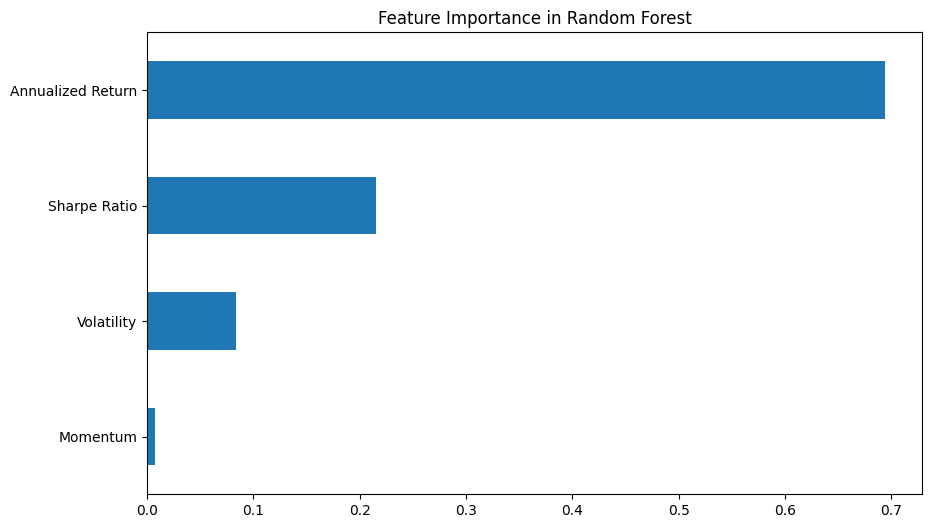

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

# Plot feature importance
feature_importance.sort_values().plot(kind='barh', figsize=(10,6), title="Feature Importance in Random Forest")
plt.show()


In [ ]:
# Get feature importances
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

# Print feature importance values
print("Feature Importances in Random Forest Model:")
print(feature_importance.sort_values(ascending=False))

Feature Importances in Random Forest Model:
Annualized Return    0.694029
Sharpe Ratio         0.215121
Volatility           0.083427
Momentum             0.007423
dtype: float64


In [ ]:
df_all["RF_Selection_Probability"] = rf_model.predict_proba(X)[:, 1]  # Probability of being in the "selected" class

# Print stocks sorted by probability
print(df_all[["Ticker", "RF_Selection_Probability", "Sharpe Ratio", "Annualized Return"]]
      .sort_values(by="RF_Selection_Probability", ascending=False))


           Ticker  RF_Selection_Probability  Sharpe Ratio  Annualized Return
78             GE                       1.0      1.607094           0.478459
59             MA                       1.0      0.922079           0.202627
51           META                       1.0      1.102644           0.503807
20  ULTRACEMCO.NS                       1.0      0.806631           0.189138
26        NTPC.NS                       1.0      1.364458           0.364827
..            ...                       ...           ...                ...
31  BAJAJFINSV.NS                       0.0      0.331906           0.087062
55            JNJ                       0.0      0.275020           0.045242
36    DIVISLAB.NS                       0.0      0.515599           0.141745
46           MSFT                       0.0      0.533631           0.145045
39  INDUSINDBK.NS                       0.0      0.287357           0.086554

[79 rows x 4 columns]


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Extract a single decision tree from the forest
tree = rf_model.estimators_[0]  # Pick the first tree

# Print the decision tree structure
print(export_text(tree, feature_names=list(X.columns)))


|--- Volatility <= 0.23
|   |--- Annualized Return <= 0.14
|   |   |--- class: 0.0
|   |--- Annualized Return >  0.14
|   |   |--- class: 1.0
|--- Volatility >  0.23
|   |--- Annualized Return <= 0.16
|   |   |--- class: 0.0
|   |--- Annualized Return >  0.16
|   |   |--- class: 1.0



In [ ]:
selected_stocks = df_all[df_all["Predicted_Label"] == 1]
rejected_stocks = df_all[df_all["Predicted_Label"] == 0]

print("Selected Stocks:")
print(selected_stocks[["Ticker", "Sharpe Ratio", "Annualized Return"]])

print("\nRejected Stocks:")
print(rejected_stocks[["Ticker", "Sharpe Ratio", "Annualized Return"]])


Selected Stocks:
           Ticker  Sharpe Ratio  Annualized Return
1           LT.NS      0.974296           0.237924
2    ICICIBANK.NS      1.075582           0.206343
3   COCHINSHIP.BO      1.706464           0.917199
4         SBIN.NS      0.703643           0.175917
5   BHARTIARTL.NS      1.485198           0.315072
11         ITC.NS      1.318939           0.257006
15     HCLTECH.NS      0.804732           0.184651
16      MARUTI.NS      0.806321           0.176973
18   SUNPHARMA.NS      1.321725           0.253926
20  ULTRACEMCO.NS      0.806631           0.189138
24   POWERGRID.NS      0.914862           0.241663
25        ONGC.NS      0.703269           0.232014
26        NTPC.NS      1.364458           0.364827
27   TATASTEEL.NS      0.706412           0.464043
28    JSWSTEEL.NS      0.677591           0.183477
30  ADANIPORTS.NS      0.565913           0.230069
32        BPCL.NS      0.678776           0.195787
34       CIPLA.NS      0.771465           0.180809
35   COALINDIA

In [ ]:
selected_stocks = df_all[df_all["Predicted_Label"] == 1]
len(selected_stocks)

40

Cluster Summary:
         Annualized Return  Volatility  Sharpe Ratio  Momentum  \
Cluster                                                          
1                 0.303007    0.293478      0.776281  0.851852   
2                 0.103434    0.240961      0.148138  0.260870   
0                 0.098942    0.542346      0.015107  0.500000   

                                                    Ticker  
Cluster                                                     
1        ICICIBANK.NS, COCHINSHIP.BO, BHARTIARTL.NS, IT...  
2        HDFCBANK.NS, LT.NS, SBIN.NS, NIFTYBEES.NS, SET...  
0        TATASTEEL.NS, ADANIGREEN.NS, TSLA, BABA, PYPL,...  

Best Stocks:
           Ticker  Annualized Return  Volatility  Sharpe Ratio  Momentum
2    ICICIBANK.NS           0.206343    0.191843      0.721126      True
3   COCHINSHIP.BO           0.917199    0.537485      1.579949     False
5   BHARTIARTL.NS           0.315072    0.212141      1.164657      True
11         ITC.NS           0.260106    0

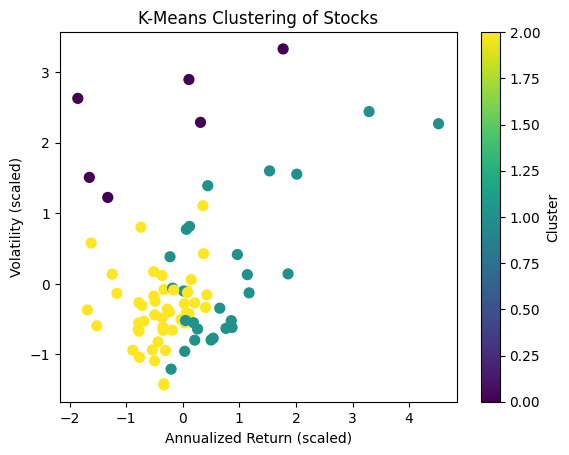

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Define tickers and other parameters (as provided in your code)
indian_tickers = [
    'HDFCBANK.NS', 'LT.NS', 'ICICIBANK.NS', 'COCHINSHIP.BO', 'SBIN.NS', 'BHARTIARTL.NS',
    'NIFTYBEES.NS', 'SETFNIF50.NS', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS',
    'KOTAKBANK.NS', 'AXISBANK.NS', 'HINDUNILVR.NS', 'HCLTECH.NS', 'MARUTI.NS', 'ASIANPAINT.NS',
    'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'BAJFINANCE.NS', 'NESTLEIND.NS',
    'POWERGRID.NS', 'ONGC.NS', 'NTPC.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS', 'ADANIGREEN.NS',
    'ADANIPORTS.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
    'DIVISLAB.NS', 'GRASIM.NS', 'HEROMOTOCO.NS', 'INDUSINDBK.NS'
]

us_tickers = [
    'TSLA', 'BRK-B', 'JPM', 'GC=F', 'NVDA', 'AAPL', 'MSFT', 'BTC-USD', 'SI=F',
    'AMZN', 'GOOGL', 'META', 'NFLX', 'BABA', 'V', 'JNJ', 'WMT', 'PG', 'DIS',
    'MA', 'HD', 'PYPL', 'INTC', 'CSCO', 'PFE', 'KO', 'PEP', 'MRK', 'ABBV',
    'ORCL', 'CRM', 'ADBE', 'CMCSA', 'XOM', 'CVX', 'NKE', 'MCD', 'IBM', 'GE'
]

all_tickers = indian_tickers + us_tickers
start_date = "2022-03-01"
end_date = "2025-03-01"
usd_to_inr = 81  # Exchange rate
risk_free_rate = 0.068  # Risk-free rate of 6.8%

# Step 1: Download historical data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_date, end=end_date)
    if ticker in us_tickers:  # Convert USD to INR
        df[['Open', 'High', 'Low', 'Close']] *= usd_to_inr
    df["Daily Return"] = df["Close"].pct_change()
    return df

# Step 2: Compute financial metrics
def compute_metrics(ticker):
    df = get_stock_data(ticker).dropna()
    metrics = {}
    metrics["Ticker"] = ticker
    metrics["Annualized Return"] = df["Daily Return"].mean() * 252
    metrics["Volatility"] = df["Daily Return"].std() * np.sqrt(252)
    metrics["Sharpe Ratio"] = (metrics["Annualized Return"] - risk_free_rate) / metrics["Volatility"] if metrics["Volatility"] > 0 else 0
    metrics["Momentum"] = (df["Close"].rolling(50).mean() > df["Close"].rolling(200).mean()).iloc[-1]
    return metrics

# Collect all stock data
data = [compute_metrics(ticker) for ticker in all_tickers]
df_all = pd.DataFrame(data).dropna()

# Step 3: Prepare data for clustering
X = df_all[["Annualized Return", "Volatility", "Sharpe Ratio", "Momentum"]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # You can adjust the number of clusters
df_all["Cluster"] = kmeans.fit_predict(X_scaled)

# Step 5: Analyze clusters
df_all['Ticker'] = df_all['Ticker'].astype(str)
cluster_summary = df_all.groupby("Cluster").agg({
    "Annualized Return": "mean",
    "Volatility": "mean",
    "Sharpe Ratio": "mean",
    "Momentum": "mean",  # Calculate mean for numeric features
    "Ticker": lambda x: ', '.join(x)  # Join tickers in each cluster as a string
}).sort_values(by="Sharpe Ratio", ascending=False)

print("Cluster Summary:")
print(cluster_summary)


# Step 6: Select the best cluster
best_cluster = cluster_summary.index[0]  # Cluster with the highest Sharpe Ratio
best_stocks = df_all[df_all["Cluster"] == best_cluster]
print("\nBest Stocks:")
print(best_stocks[["Ticker", "Annualized Return", "Volatility", "Sharpe Ratio", "Momentum"]])

# Step 7: Visualize clusters (optional)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df_all["Cluster"], cmap="viridis", s=50)
plt.xlabel("Annualized Return (scaled)")
plt.ylabel("Volatility (scaled)")
plt.title("K-Means Clustering of Stocks")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
indian_tickers = [
    'HDFCBANK.NS', 'LT.NS', 'ICICIBANK.NS', 'COCHINSHIP.BO', 'SBIN.NS', 'BHARTIARTL.NS',
    'NIFTYBEES.NS', 'SETFNIF50.NS', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS',
    'KOTAKBANK.NS', 'AXISBANK.NS', 'HINDUNILVR.NS', 'HCLTECH.NS', 'MARUTI.NS', 'ASIANPAINT.NS',
    'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'BAJFINANCE.NS', 'NESTLEIND.NS',
    'POWERGRID.NS', 'ONGC.NS', 'NTPC.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS', 'ADANIGREEN.NS',
    'ADANIPORTS.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
    'DIVISLAB.NS', 'GRASIM.NS', 'HEROMOTOCO.NS', 'INDUSINDBK.NS', 'DRREDDY.NS', 'EICHERMOT.NS',
    'GAIL.NS', 'HDFCLIFE.NS', 'HINDALCO.NS', 'IOC.NS', 'M&M.NS', 'SHREECEM.NS', 'TATAMOTORS.NS',
    'UPL.NS', 'VEDL.NS', 'ZEEL.NS', 'BAJAJ-AUTO.NS', 'BHARATFORG.NS', 'DABUR.NS', 'HAVELLS.NS',
    'JINDALSTEL.NS', 'LUPIN.NS', 'PIDILITIND.NS', 'SIEMENS.NS', 'TORNTPHARM.NS', 'AMBUJACEM.NS',
    'AUROPHARMA.NS', 'BANKBARODA.NS', 'BEL.NS', 'BHEL.NS', 'CADILAHC.NS', 'CANBK.NS', 'COLPAL.NS',
    'CONCOR.NS', 'CUMMINSIND.NS', 'DLF.NS', 'ESCORTS.NS', 'EXIDEIND.NS', 'FEDERALBNK.NS', 'GODREJCP.NS',
    'GODREJIND.NS', 'HINDPETRO.NS', 'IDEA.NS', 'INDIGO.NS', 'JUBLFOOD.NS', 'LICHSGFIN.NS', 'MANAPPURAM.NS',
    'MARICO.NS', 'MCDOWELL-N.NS', 'MINDTREE.NS', 'MOTHERSUMI.NS', 'MRF.NS', 'NAM-INDIA.NS', 'NMDC.NS',
    'PEL.NS', 'PETRONET.NS', 'PFC.NS', 'PNB.NS', 'SAIL.NS', 'SRF.NS', 'SRTRANSFIN.NS', 'TATACHEM.NS',
    'TATACOMM.NS', 'TATAPOWER.NS', 'TVSMOTOR.NS', 'UBL.NS', 'VOLTAS.NS', 'YESBANK.NS', 'ZYDUSWELL.NS'
]

In [ ]:
len( indian_tickers )

105

In [ ]:
len(us_tickers)

115

In [ ]:
us_tickers = [
    'TSLA', 'BRK-B', 'JPM', 'GC=F', 'NVDA', 'AAPL', 'MSFT', 'BTC-USD', 'SI=F',
    'AMZN', 'GOOGL', 'META', 'NFLX', 'BABA', 'V', 'JNJ', 'WMT', 'PG', 'DIS',
    'MA', 'HD', 'PYPL', 'INTC', 'CSCO', 'PFE', 'KO', 'PEP', 'MRK', 'ABBV',
    'ORCL', 'CRM', 'ADBE', 'CMCSA', 'XOM', 'CVX', 'NKE', 'MCD', 'IBM', 'GE',
    'BA', 'CAT', 'CVS', 'DHR', 'GS', 'HON', 'INTU', 'LLY', 'LMT', 'MO',
    'MS', 'NEE', 'PEP', 'QCOM', 'RTX', 'T', 'TMO', 'UNH', 'VZ', 'WBA',
    'WFC', 'ABT', 'ACN', 'ADP', 'AMD', 'AXP', 'BKNG', 'BLK', 'BMY', 'C',
    'CHTR', 'CL', 'COST', 'DE', 'DOW', 'DUK', 'EMR', 'F', 'FDX', 'GD',
    'GILD', 'GM', 'GOOG', 'HCA', 'HPQ', 'ICE', 'ISRG', 'JCI', 'KHC', 'LIN',
    'LOW', 'MDT', 'MET', 'MMM', 'NOC', 'NSC', 'NUE', 'PGR', 'PLD', 'PM',
    'PYPL', 'REGN', 'ROST', 'SBUX', 'SO', 'SPG', 'TGT', 'TJX', 'TXN', 'UNP',
    'UPS', 'USB', 'VRTX', 'WMB', 'XEL', 'ZTS'
]

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Define tickers and other parameters (as provided in your code)
# indian_tickers = [
#     'HDFCBANK.NS', 'LT.NS', 'ICICIBANK.NS', 'COCHINSHIP.BO', 'SBIN.NS', 'BHARTIARTL.NS',
#     'NIFTYBEES.NS', 'SETFNIF50.NS', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS',
#     'KOTAKBANK.NS', 'AXISBANK.NS', 'HINDUNILVR.NS', 'HCLTECH.NS', 'MARUTI.NS', 'ASIANPAINT.NS',
#     'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'BAJFINANCE.NS', 'NESTLEIND.NS',
#     'POWERGRID.NS', 'ONGC.NS', 'NTPC.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS', 'ADANIGREEN.NS',
#     'ADANIPORTS.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
#     'DIVISLAB.NS', 'GRASIM.NS', 'HEROMOTOCO.NS', 'INDUSINDBK.NS'
# ]

# us_tickers = [
#     'TSLA', 'BRK-B', 'JPM', 'GC=F', 'NVDA', 'AAPL', 'MSFT', 'BTC-USD', 'SI=F',
#     'AMZN', 'GOOGL', 'META', 'NFLX', 'BABA', 'V', 'JNJ', 'WMT', 'PG', 'DIS',
#     'MA', 'HD', 'PYPL', 'INTC', 'CSCO', 'PFE', 'KO', 'PEP', 'MRK', 'ABBV',
#     'ORCL', 'CRM', 'ADBE', 'CMCSA', 'XOM', 'CVX', 'NKE', 'MCD', 'IBM', 'GE'
# ]

all_tickers = indian_tickers + us_tickers
start_date = "2022-03-01"
end_date = "2025-03-01"
usd_to_inr = 81  # Exchange rate
risk_free_rate = 0.068  # Risk-free rate of 6.8%

# Step 1: Download historical data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_date, end=end_date)
    if ticker in us_tickers:  # Convert USD to INR
        df[['Open', 'High', 'Low', 'Close']] *= usd_to_inr
    df["Daily Return"] = df["Close"].pct_change()
    return df

# Step 2: Compute financial metrics with error handling
def compute_metrics(ticker):
    try:
        df = get_stock_data(ticker).dropna()
        metrics = {}
        metrics["Ticker"] = ticker
        metrics["Annualized Return"] = df["Daily Return"].mean() * 252
        metrics["Volatility"] = df["Daily Return"].std() * np.sqrt(252)
        metrics["Sharpe Ratio"] = (metrics["Annualized Return"] - risk_free_rate) / metrics["Volatility"] if metrics["Volatility"] > 0 else 0
        metrics["Momentum"] = (df["Close"].rolling(50).mean() > df["Close"].rolling(200).mean()).iloc[-1]
        return metrics
    except Exception as e:
        print(f"Error processing {ticker}: {e}")  # Print the error message
        return None  # Return None to indicate failure

# Collect all stock data and remove None values
data = [compute_metrics(ticker) for ticker in all_tickers]
# Filter out None values from the data list
data = [d for d in data if d is not None]  # remove None to avoid the AttributeError
df_all = pd.DataFrame(data).dropna()

# Step 3: Label stocks based on Sharpe Ratio
# Define "good" stocks as those with a Sharpe Ratio above the median
median_sharpe = df_all["Sharpe Ratio"].median()
df_all["Label"] = df_all["Sharpe Ratio"].apply(lambda x: 1 if x > median_sharpe else 0)

# Step 4: Prepare data for Gradient Boosting
X = df_all[["Annualized Return", "Volatility", "Sharpe Ratio", "Momentum"]]
y = df_all["Label"]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = gb_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 7: Predict the best stocks
df_all["Predicted Label"] = gb_model.predict(X_scaled)
best_stocks = df_all[df_all["Predicted Label"] == 1]
print("\nBest Stocks (Predicted by Gradient Boosting):")
print(best_stocks[["Ticker", "Annualized Return", "Volatility", "Sharpe Ratio", "Momentum"]])

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.88      1.00      0.93         7

    accuracy                           0.94        16
   macro avg       0.94      0.94      0.94        16
weighted avg       0.95      0.94      0.94        16

Accuracy: 0.9375

Best Stocks (Predicted by Gradient Boosting):
           Ticker  Annualized Return  Volatility  Sharpe Ratio  Momentum
1           LT.NS           0.237924    0.244201      0.695836     False
2    ICICIBANK.NS           0.206343    0.191843      0.721126      True
3   COCHINSHIP.BO           0.917199    0.537485      1.579949     False
4         SBIN.NS           0.175917    0.250009      0.431652     False
5   BHARTIARTL.NS           0.315072    0.212141      1.164657      True
6    NIFTYBEES.NS           0.116677    0.120381      0.404356     False
7    SETFNIF50.NS           0.116125    0.122228      0.393732     False
11

In [ ]:
['LT.NS', 'ICICIBANK.NS', 'COCHINSHIP.BO', 'SBIN.NS', 'BHARTIARTL.NS', 'NIFTYBEES.NS', 'SETFNIF50.NS', 'ITC.NS', 'HCLTECH.NS', 'MARUTI.NS', 'SUNPHARMA.NS', 'ULTRACEMCO.NS', 'POWERGRID.NS', 'ONGC.NS', 'NTPC.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS', 'ADANIPORTS.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'GRASIM.NS', 'HEROMOTOCO.NS', 'BRK-B', 'JPM', 'GC=F', 'NVDA', 'AAPL', 'BTC-USD', 'META', 'NFLX', 'V', 'WMT', 'MA', 'ABBV', 'ORCL', 'XOM', 'IBM', 'GE']